# 03 SP - Modelagem: Clustering de Setores Censitários (SP)

Mesmo pipeline do BA:
1. UMAP visualização 2D
2. HDBSCAN sobre features originais
3. Silhouette score
4. Heatmap de perfil dos clusters
5. Mapa geográfico

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
import hdbscan
import umap
from pathlib import Path

OUTPUT_DIR = Path('../outputs')

df = pd.read_parquet(OUTPUT_DIR / 'setores_features_sp.parquet')

FEATURES = [
    'prop_domicilio_particular', 'prop_domicilio_coletivo',
    'prop_estab_agropecuario', 'prop_estab_ensino', 'prop_estab_saude',
    'prop_estab_outras', 'prop_construcao', 'prop_estab_religioso',
    'prop_finalidade_residencial', 'prop_finalidade_comercial', 'prop_finalidade_mista'
]

X = df[FEATURES].values
print(f'Setores: {len(df):,} | Features: {X.shape[1]}')

Setores: 98,902 | Features: 11


/home/wesleiferreira/Documentos/GitHub/trabalho-topicos-4/.venv/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


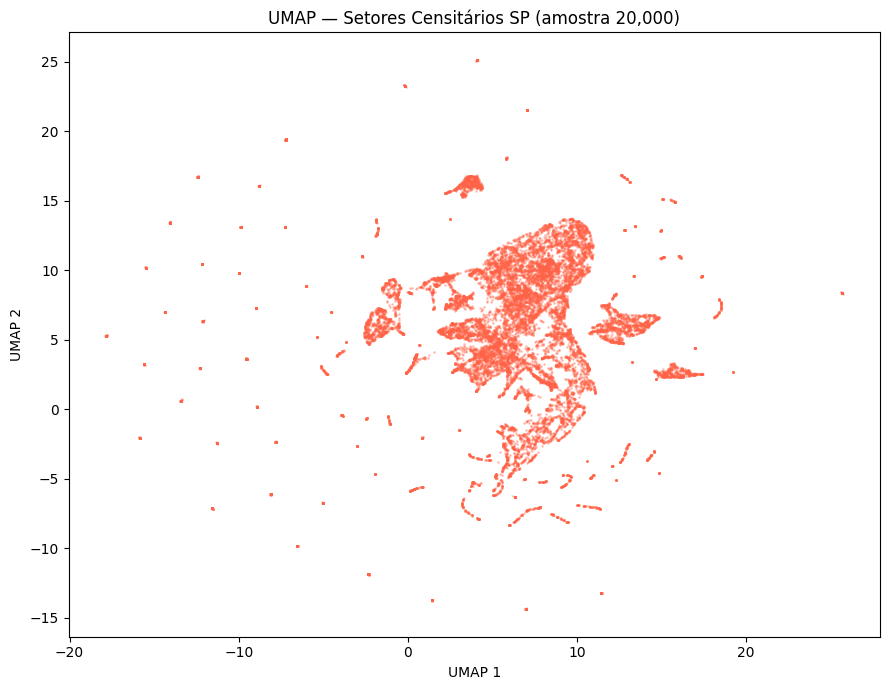

In [2]:
# UMAP — apenas visualização, roda sobre amostra de 20k para não travar
UMAP_SAMPLE = 20_000
rng = np.random.default_rng(42)
idx_sample = rng.choice(len(df), size=min(UMAP_SAMPLE, len(df)), replace=False)
idx_sample.sort()

X_sample = X[idx_sample]

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    n_epochs=200, random_state=42)
embedding_sample = reducer.fit_transform(X_sample)

# guarda coordenadas UMAP só nos pontos amostrados
df['umap_x'] = np.nan
df['umap_y'] = np.nan
df.iloc[idx_sample, df.columns.get_loc('umap_x')] = embedding_sample[:, 0]
df.iloc[idx_sample, df.columns.get_loc('umap_y')] = embedding_sample[:, 1]

df_umap = df.iloc[idx_sample].copy()

plt.figure(figsize=(9, 7))
plt.scatter(df_umap['umap_x'], df_umap['umap_y'], s=1, alpha=0.3, c='tomato')
plt.title(f'UMAP — Setores Censitários SP (amostra {UMAP_SAMPLE:,})')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/sp_umap_setores.png', dpi=150)
plt.show()

In [3]:
# HDBSCAN sobre features originais
# min_cluster_size escalado para o tamanho do dataset (~98k setores)
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=600,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)
labels = clusterer.fit_predict(X)
df['cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
print(f'Clusters encontrados : {n_clusters}')
print(f'Ruído (-1)           : {n_noise:,} ({n_noise/len(df)*100:.1f}%)')
print()
print(df['cluster'].value_counts().sort_index())

Clusters encontrados : 12
Ruído (-1)           : 56,630 (57.3%)

cluster
-1     56630
 0      1382
 1       688
 2      1738
 3      1947
 4     11210
 5      2831
 6      1369
 7      7864
 8      6821
 9      1142
 10     1834
 11     3446
Name: count, dtype: int64


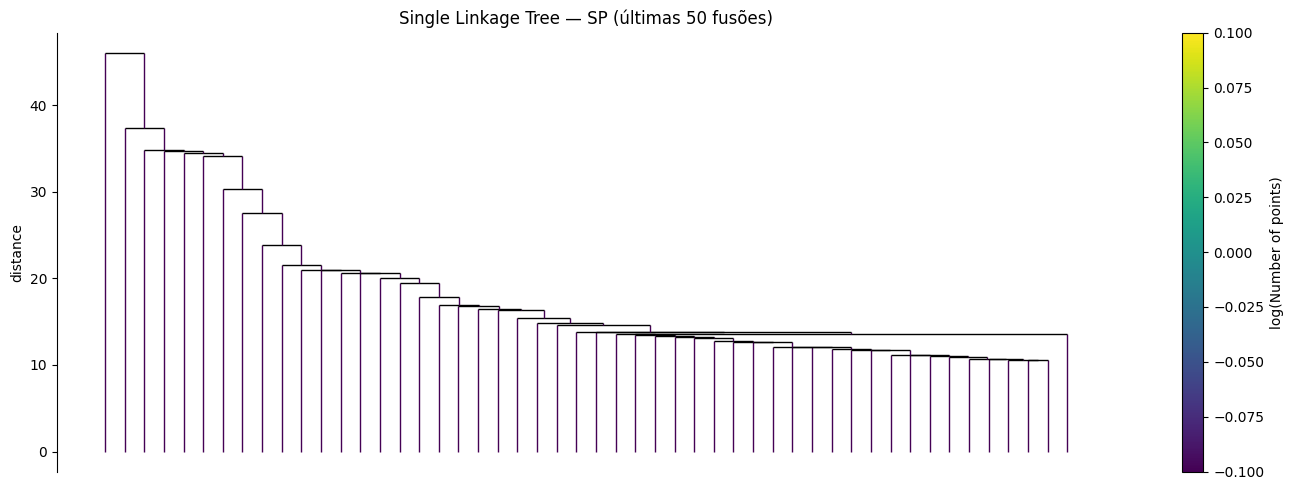

In [4]:
# Single Linkage Tree — vary_line_width=False evita RecursionError em datasets grandes
fig, ax = plt.subplots(figsize=(14, 5))
clusterer.single_linkage_tree_.plot(
    truncate_mode='lastp', p=50,
    vary_line_width=False,
    cmap='viridis', colorbar=True, axis=ax
)
ax.set_title('Single Linkage Tree — SP (últimas 50 fusões)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/sp_single_linkage_tree.png', dpi=150)
plt.show()

In [5]:
# Silhouette no espaço original
mask = df['cluster'] != -1
if mask.sum() > 1 and df.loc[mask, 'cluster'].nunique() > 1:
    score = silhouette_score(X[mask], df.loc[mask, 'cluster'], sample_size=10000, random_state=42)
    print(f'Silhouette Score (SP): {score:.4f}')

Silhouette Score (SP): 0.1360


In [6]:
# Nomenclatura adaptativa — sem sufixo numérico
NOMES_NRES = {
    'prop_estab_agropecuario':  'Rural / Agropecuário',
    'prop_estab_ensino':        'Educacional',
    'prop_estab_saude':         'Saúde',
    'prop_estab_outras':        'Comercial / Serviços',
    'prop_construcao':          'Em Construção',
    'prop_estab_religioso':     'Religioso',
    'prop_finalidade_comercial':'Comercial / Serviços',
    'prop_finalidade_mista':    'Uso Misto',
    'prop_domicilio_coletivo':  'Domicílio Coletivo',
}

perfil_z = df[df['cluster'] != -1].groupby('cluster')[FEATURES].mean()

def nomear(row):
    if row['prop_finalidade_mista'] > 0.5:
        return 'Uso Misto'
    if row['prop_domicilio_coletivo'] > 0.5:
        return 'Domicílio Coletivo'
    best_feat = max(NOMES_NRES, key=lambda f: row[f])
    best_z    = row[best_feat]
    dom_res   = row['prop_domicilio_particular']
    if best_z >= 0.2:
        prefixo = 'Residencial + ' if dom_res >= 0.2 else ''
        return f'{prefixo}{NOMES_NRES[best_feat]}'
    if dom_res >= 0.8:
        return 'Residencial Puro'
    if dom_res >= 0.4:
        return 'Residencial'
    return 'Residencial Típico'

nomes_finais = {cid: nomear(row) for cid, row in perfil_z.iterrows()}
df['cluster_nome'] = df['cluster'].map(lambda x: nomes_finais.get(x, 'Ruído') if x != -1 else 'Ruído')

print('Tipos de cluster (SP):')
tamanhos_nome = df[df['cluster'] != -1]['cluster_nome'].value_counts().sort_index()
for nome, n in tamanhos_nome.items():
    print(f'  {nome:<45} (n={n:,})')

Tipos de cluster (SP):
  Residencial                                   (n=11,409)
  Residencial + Comercial / Serviços            (n=2,426)
  Residencial + Educacional                     (n=4,778)
  Residencial + Religioso                       (n=11,210)
  Residencial + Saúde                           (n=1,369)
  Residencial Puro                              (n=9,698)
  Uso Misto                                     (n=1,382)


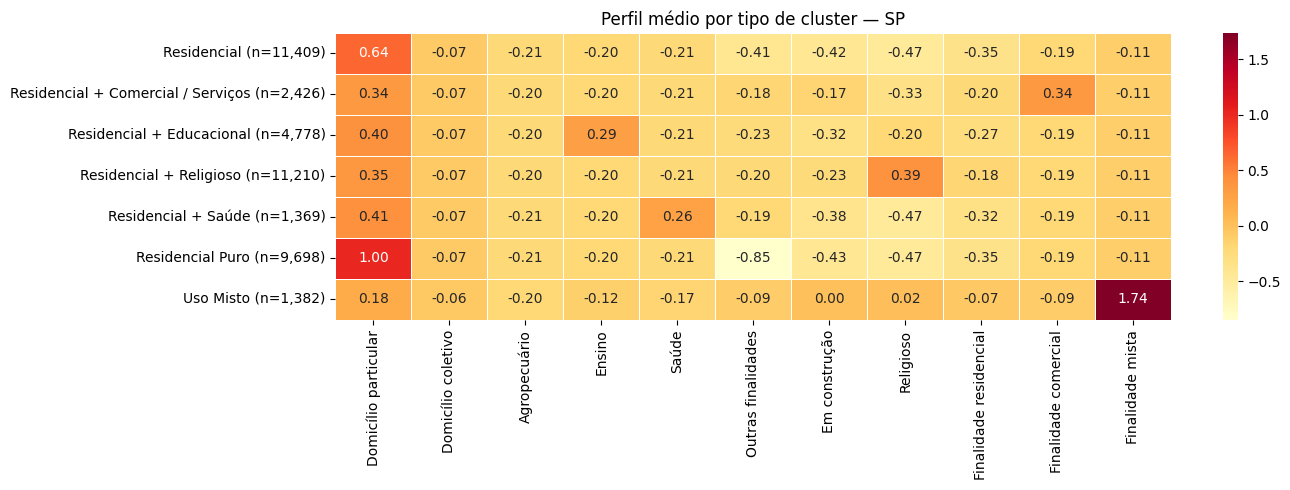

In [7]:
# Heatmap — agrega por cluster_nome
FEATURES_LABEL = {
    'prop_domicilio_particular':  'Domicílio particular',
    'prop_domicilio_coletivo':    'Domicílio coletivo',
    'prop_estab_agropecuario':    'Agropecuário',
    'prop_estab_ensino':          'Ensino',
    'prop_estab_saude':           'Saúde',
    'prop_estab_outras':          'Outras finalidades',
    'prop_construcao':            'Em construção',
    'prop_estab_religioso':       'Religioso',
    'prop_finalidade_residencial':'Finalidade residencial',
    'prop_finalidade_comercial':  'Finalidade comercial',
    'prop_finalidade_mista':      'Finalidade mista',
}

perfil = (df[df['cluster'] != -1]
          .groupby('cluster_nome')[FEATURES]
          .mean()
          .rename(columns=FEATURES_LABEL))

tamanhos_nome = df[df['cluster'] != -1]['cluster_nome'].value_counts()
perfil.index = [f"{nome} (n={tamanhos_nome[nome]:,})" for nome in perfil.index]

fig, ax = plt.subplots(figsize=(14, max(5, len(perfil) * 0.55 + 1)))
sns.heatmap(perfil, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Perfil médio por tipo de cluster — SP')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/sp_perfil_clusters_heatmap.png', dpi=150)
plt.show()

In [ ]:
# UMAP colorido por cluster com nomes
CORES_FORTES = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
                '#00b4d8','#f032e6','#bfef45','#9A6324','#469990',
                '#800000','#000075','#ff6b6b','#06d6a0','#ffd166']

df_umap = df.iloc[idx_sample].copy()
nomes_unicos = sorted(df_umap[df_umap['cluster'] != -1]['cluster_nome'].unique())
palette_nomes = {n: CORES_FORTES[i % len(CORES_FORTES)] for i, n in enumerate(nomes_unicos)}

fig, ax = plt.subplots(figsize=(11, 8))
noise_umap = df_umap[df_umap['cluster'] == -1]
ax.scatter(noise_umap['umap_x'], noise_umap['umap_y'], s=1, c='#cccccc', alpha=0.2, label='Ruído')

for nome in nomes_unicos:
    sub = df_umap[df_umap['cluster_nome'] == nome]
    ax.scatter(sub['umap_x'], sub['umap_y'], s=4, alpha=0.8,
               color=palette_nomes[nome], label=f'{nome} (n={len(sub):,})')

ax.legend(markerscale=4, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_title(f'Clusters — UMAP + HDBSCAN SP (amostra {UMAP_SAMPLE:,})')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/sp_clusters_umap.png', dpi=150)
plt.show()

In [ ]:
# Mapa geográfico com nomes
noise = df[df['cluster'] == -1]
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(noise['lon_centroide'], noise['lat_centroide'], s=0.3, c='#cccccc', alpha=0.1)

for nome in nomes_unicos:
    sub = df[df['cluster_nome'] == nome]
    ax.scatter(sub['lon_centroide'], sub['lat_centroide'], s=2, alpha=0.7,
               color=palette_nomes[nome], label=nome)

ax.legend(markerscale=6, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_title('Mapa de Setores — Clusters (SP)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/sp_clusters_mapa_geo.png', dpi=150)
plt.show()

In [10]:
df.to_parquet(OUTPUT_DIR / 'setores_clusterizados_sp.parquet', index=False)
print('Salvo: outputs/setores_clusterizados_sp.parquet')

Salvo: outputs/setores_clusterizados_sp.parquet
